===============================================
ВНИМАНИЕ!!!! ЭТА ЧАСТЬ КОДА ВЫПОЛНЯеТСЯ НА CPU
===============================================

In [3]:
import sys
sys.path.append('.')

from src.data_utils import load_data, prepare_dataset, split_data
from src.dataset import NextTokenDataset
import torch
from torch.utils.data import DataLoader

print("Все модули успешно импортированы!")

Все модули успешно импортированы!


In [4]:

df_raw = load_data('data/training.1600000.processed.noemoticon.csv', n_rows=100000)

df_clean = prepare_dataset(df_raw)

print("\nПримеры очищенных текстов:")
for i in range(3):
    print(f"  {i+1}. {df_clean['clean_text'].iloc[i]}")
    print(f"     Токены: {df_clean['tokens'].iloc[i]}")
    print()

Загрузка данных из data/training.1600000.processed.noemoticon.csv...
Загружено 100000 строк
Очистка текстов...
Токенизация...
Готово! 99828 примеров

Примеры очищенных текстов:
  1. a thats a bummer. you shoulda got david carr of third day to do it. d
     Токены: ['a', 'thats', 'a', 'bummer.', 'you', 'shoulda', 'got', 'david', 'carr', 'of', 'third', 'day', 'to', 'do', 'it.', 'd']

  2. is upset that he cant update his facebook by texting it... and might cry as a result school today also. blah!
     Токены: ['is', 'upset', 'that', 'he', 'cant', 'update', 'his', 'facebook', 'by', 'texting', 'it...', 'and', 'might', 'cry', 'as', 'a', 'result', 'school', 'today', 'also.', 'blah!']

  3. i dived many times for the ball. managed to save 50 the rest go out of bounds
     Токены: ['i', 'dived', 'many', 'times', 'for', 'the', 'ball.', 'managed', 'to', 'save', '50', 'the', 'rest', 'go', 'out', 'of', 'bounds']



In [5]:
train, val, test = split_data(df_clean)

print("\nПроверяем сохраненные файлы:")
!ls -la data/

Train: 79863 примеров
Val: 9982 примеров
Test: 9983 примеров

Проверяем сохраненные файлы:
total 257912
drwxr-xr-x 2 root root      4096 Mar 16 09:49 .
drwxr-xr-x 1 root root      4096 Mar 16 16:15 ..
-rw-r--r-- 1 root root        50 Mar 15 11:38 file_from_visible_folders.txt
-rw-r--r-- 1 root root   2517052 Mar 16 16:16 test.csv
-rw-r--r-- 1 root root  20219003 Mar 16 16:16 train.csv
-rw-rw-r-- 1 root root 238803811 Mar 16 09:45 training.1600000.processed.noemoticon.csv
-rw-r--r-- 1 root root   2538328 Mar 16 16:16 val.csv


In [6]:
from torch.nn.utils.rnn import pad_sequence

def collate_batch(batch):
    inputs, targets = zip(*batch)

    inputs_padded = pad_sequence(inputs, batch_first=True, padding_value=0)
    targets_padded = pad_sequence(targets, batch_first=True, padding_value=0)

    return inputs_padded, targets_padded

train_dataset = NextTokenDataset('data/train.csv', max_len=20)
val_dataset = NextTokenDataset('data/val.csv', max_len=20)
test_dataset = NextTokenDataset('data/test.csv', max_len=20)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=0
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=0
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=0
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Загружено 62900 примеров
Размер словаря: 63133
Загружено 7807 примеров
Размер словаря: 15055
Загружено 7925 примеров
Размер словаря: 14959

Train batches: 1966
Val batches: 244
Test batches: 248


In [7]:
x, y = next(iter(train_loader))
print(f"Форма входных данных: {x.shape}")
print(f"Форма целевых данных: {y.shape}")
print(f"Размер словаря: {train_dataset.vocab_size}")
print(f"Индекс паддинга: {train_dataset.pad_idx}")

print(f"\nПервый пример входа: {x[0][:10]}...")
print(f"Первый пример цели: {y[0][:10]}...")

Форма входных данных: torch.Size([32, 19])
Форма целевых данных: torch.Size([32, 19])
Размер словаря: 63133
Индекс паддинга: 0

Первый пример входа: tensor([  34,   23,    3,   77, 9420, 5520,  461,  318,   23,  254])...
Первый пример цели: tensor([  23,    3,   77, 9420, 5520,  461,  318,   23,  254,  216])...


In [8]:
from src.lstm_model import LSTMAutocomplete

vocab_size = train_dataset.vocab_size
pad_idx = train_dataset.pad_idx

model = LSTMAutocomplete(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.3,
    pad_idx=pad_idx
)

print(model)
print(f"\nВсего параметров: {sum(p.numel() for p in model.parameters())}")

LSTMAutocomplete(
  (embedding): Embedding(63133, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=63133, bias=True)
)

Всего параметров: 25227805


In [9]:
x, y = next(iter(train_loader))

with torch.no_grad():
    outputs = model(x)

print(f"Вход: {x.shape}")
print(f"Выход: {outputs.shape}")  # (batch_size, seq_len, vocab_size)
print(f"Логиты для первого токена первого примера: {outputs[0, 0, :5]}...")

Вход: torch.Size([32, 19])
Выход: torch.Size([32, 19, 63133])
Логиты для первого токена первого примера: tensor([ 0.0318,  0.0055, -0.0827,  0.0638,  0.0360])...


In [10]:
sample_idx = 0
sample_tokens = train_dataset.df.iloc[sample_idx]['token_list']
print(f"Полный текст: {' '.join(sample_tokens)}")

start_tokens = train_dataset.text_to_ids(sample_tokens[:3])
print(f"Начало (3 токена): {train_dataset.ids_to_text(start_tokens)}")

generated_ids = model.generate(start_tokens, max_new_tokens=5)
generated_text = train_dataset.ids_to_text(generated_ids)
print(f"Сгенерировано: {generated_text}")

Полный текст: another day at work working on the weekend sucks but the moneys pretty good. time to bite the bullet.
Начало (3 токена): another day at
Сгенерировано: another day at okayy texting, okayy frequency hot30


In [ ]:
!zip -r data.zip data/ src/
print("Данные подготовлены!")

=========================================================
ВНИМАНИЕ !!! ЭТА ЧАСТЬ КОДА ВЫПОЛНЯЕТСЯ НА Colab Notebook
=========================================================

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/drive/MyDrive/text-autocomplete/data.zip ./

!unzip -o data.zip

!ls -la
!ls -la data/
!ls -la src/

Mounted at /content/drive
Archive:  data.zip
   creating: data/
  inflating: data/val.csv            
  inflating: data/test.csv           
  inflating: data/training.1600000.processed.noemoticon.csv  
  inflating: data/train.csv          
 extracting: data/file_from_visible_folders.txt  
   creating: src/
  inflating: src/dataset.py          
  inflating: src/data_utils.py       
  inflating: src/evaluate.py         
  inflating: src/lstm_model.py       
  inflating: src/train_lstm.py       
total 91044
drwxr-xr-x 1 root root     4096 Mar 16 16:15 .
drwxr-xr-x 1 root root     4096 Mar 16 16:09 ..
drwxr-xr-x 4 root root     4096 Feb  6 14:31 .config
drwxr-xr-x 2 root root     4096 Mar 16 09:49 data
-rw------- 1 root root 93194500 Mar 16 16:15 data.zip
drwx------ 5 root root     4096 Mar 16 16:15 drive
drwxr-xr-x 1 root root     4096 Feb  6 14:31 sample_data
drwxr-xr-x 2 root root     4096 Mar 15 07:24 src
total 257912
drwxr-xr-x 2 root root      4096 Mar 16 09:49 .
drwxr-xr-x 1 root ro

In [11]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=11d66c2a19a8098c8f84485a9171ca0b97fc809c7ecfaa85f6a70c1ad6dbe4ad
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [12]:
import sys
sys.path.append('.')

from src.data_utils import load_data, prepare_dataset, split_data
from src.dataset import NextTokenDataset
from src.lstm_model import LSTMAutocomplete
from src.train_lstm import train_lstm
from src.evaluate import evaluate_transformer, evaluate_lstm_model

import torch
import matplotlib.pyplot as plt

print("Все модули загружены!")

Все модули загружены!


In [13]:
!unzip -o /content/drive/MyDrive/data.zip


train_dataset = NextTokenDataset('data/train.csv', max_len=20)
val_dataset = NextTokenDataset('data/val.csv', max_len=20)
test_dataset = NextTokenDataset('data/test.csv', max_len=20)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=256, shuffle=True, num_workers=2
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=256, shuffle=False, num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=256, shuffle=True, num_workers=2
)

unzip:  cannot find or open /content/drive/MyDrive/data.zip, /content/drive/MyDrive/data.zip.zip or /content/drive/MyDrive/data.zip.ZIP.
Загружено 62900 примеров
Размер словаря: 63133
Загружено 7807 примеров
Размер словаря: 15055
Загружено 7925 примеров
Размер словаря: 14959


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем: {device}")

model = LSTMAutocomplete(
    vocab_size=train_dataset.vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.3,
    pad_idx=train_dataset.pad_idx
).to(device)

print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Используем: cuda
Параметров: 25,227,805


In [15]:
train_losses, val_losses, rouge_scores = train_lstm(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    dataset=train_dataset,
    device=device,
    epochs=10,
    lr=0.001
)

Начинаем тренировку...

--- Эпоха 1/10 ---


Validation: 100%|██████████| 31/31 [00:02<00:00, 13.49it/s]


Train Loss: 8.0538
Val Loss: 10.3893
ROUGE-1: 0.0300, ROUGE-2: 0.0000
Learning Rate: 0.001000

Примеры предсказаний:
  Pred: another day at to
  Ref:  work

  Pred: another on the weekend sucks but to to
  Ref:  moneys pretty

  Pred: another working time time to bite bullet. virgin megastores to to to to
  Ref:  are closing.. this is


--- Эпоха 2/10 ---


Validation: 100%|██████████| 31/31 [00:02<00:00, 12.61it/s]


Train Loss: 7.5421
Val Loss: 10.2105
ROUGE-1: 0.0342, ROUGE-2: 0.0000
Learning Rate: 0.001000

Примеры предсказаний:
  Pred: another day at the
  Ref:  work

  Pred: another on the weekend sucks but i have
  Ref:  moneys pretty

  Pred: another working time time to bite bullet. virgin megastores to the the the
  Ref:  are closing.. this is


--- Эпоха 3/10 ---


...

Train Loss: 6.3732
Val Loss: 10.4979
ROUGE-1: 0.0330, ROUGE-2: 0.0000
Learning Rate: 0.000500

Примеры предсказаний:
  Pred: another day at the
  Ref:  work

  Pred: another on the weekend sucks but i have
  Ref:  moneys pretty

  Pred: another working time time to bite bullet. virgin megastores i have to go
  Ref:  are closing.. this is


--- Эпоха 9/10 ---


Validation: 100%|██████████| 31/31 [00:02<00:00, 12.75it/s]


Train Loss: 6.3082
Val Loss: 10.5250
ROUGE-1: 0.0414, ROUGE-2: 0.0000
Learning Rate: 0.000250

Примеры предсказаний:
  Pred: another day at work
  Ref:  work

  Pred: another on the weekend sucks but i have
  Ref:  moneys pretty

  Pred: another working time time to bite bullet. virgin megastores i have to go
  Ref:  are closing.. this is


--- Эпоха 10/10 ---


Validation: 100%|██████████| 31/31 [00:02<00:00, 12.78it/s]


Train Loss: 6.2390
Val Loss: 10.5890
ROUGE-1: 0.0477, ROUGE-2: 0.0000
Learning Rate: 0.000250

Примеры предсказаний:
  Pred: another day at work
  Ref:  work

  Pred: another on the weekend sucks but i have
  Ref:  moneys pretty

  Pred: another working time time to bite bullet. virgin megastores i have to go
  Ref:  are closing.. this is



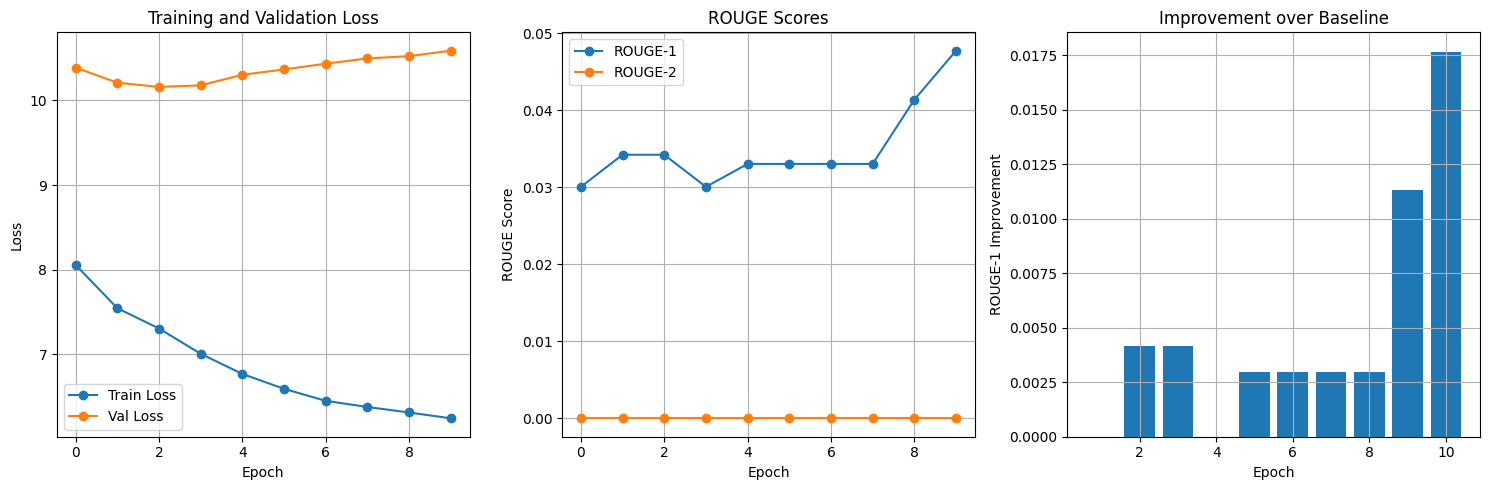

Лучший ROUGE-1: 0.0477 на эпохе 10


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
rouge1 = [r['rouge1'] for r in rouge_scores]
rouge2 = [r['rouge2'] for r in rouge_scores]
plt.plot(rouge1, label='ROUGE-1', marker='o')
plt.plot(rouge2, label='ROUGE-2', marker='o')
plt.xlabel('Epoch')
plt.ylabel('ROUGE Score')
plt.title('ROUGE Scores')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
improvement = [rouge_scores[i]['rouge1'] - rouge_scores[0]['rouge1'] for i in range(len(rouge_scores))]
plt.bar(range(1, len(improvement) + 1), improvement)
plt.xlabel('Epoch')
plt.ylabel('ROUGE-1 Improvement')
plt.title('Improvement over Baseline')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Лучший ROUGE-1: {max([r['rouge1'] for r in rouge_scores]):.4f} на эпохе {rouge_scores.index(max(rouge_scores, key=lambda x: x['rouge1'])) + 1}")

In [17]:
def test_model_completion(model, dataset, prefix_text, max_tokens=10):

    prefix_tokens = prefix_text.lower().split()
    prefix_ids = dataset.text_to_ids(prefix_tokens)

    generated_ids = model.generate(prefix_ids, max_new_tokens=max_tokens)
    full_text = dataset.ids_to_text(generated_ids)

    return full_text

# Тестовые данные
test_prefixes = [
    "i am going to",
    "today is a",
    "the weather is",
    "i really like",
    "can you help me",
    "what do you think about"
]

print("="*60)
print("ТЕСТИРОВАНИЕ МОДЕЛИ НА НОВЫХ ПРИМЕРАХ")
print("="*60)

for prefix in test_prefixes:
    completion = test_model_completion(model, train_dataset, prefix)
    print(f"\n Префикс: {prefix}")
    print(f"   Продолжение: {completion}")

ТЕСТИРОВАНИЕ МОДЕЛИ НА НОВЫХ ПРИМЕРАХ

 Префикс: i am going to
   Продолжение: i am going to be a good day of the office and i have

 Префикс: today is a
   Продолжение: today is a good day of the office of the way to the

 Префикс: the weather is
   Продолжение: the weather is so sad i cant sleep in the office and i

 Префикс: i really like
   Продолжение: i really like my phone and i have to go to work and

 Префикс: can you help me
   Продолжение: can you help me have to go to the office and i have to

 Префикс: what do you think about
   Продолжение: what do you think about the sun i have to go to the airport and


In [18]:

print("Запускаем DistilGPT2...")
rouge_tf, tf_preds, tf_refs = evaluate_transformer(
    val_dataset,
    num_samples=200
)

print(f"ROUGE-1: {rouge_tf['rouge1']:.4f}")
print(f"ROUGE-2: {rouge_tf['rouge2']:.4f}")

Запускаем DistilGPT2...

ЗАГРУЗКА TRANSFORMER МОДЕЛИ DistilGPT2
Используем устройство: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

...

Обработано 160/200 примеров


Both `max_new_tokens` (=2) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_ne

Обработано 180/200 примеров


Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=5) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_ne

Обработано 200/200 примеров

 Успешно обработано 194 примеров

 Результаты DistilGPT2:
   ROUGE-1: 0.0682
   ROUGE-2: 0.0058
ROUGE-1: 0.0682
ROUGE-2: 0.0058


In [19]:
from src.evaluate import evaluate_lstm_model

print("="*60)
print("ЗАПУСК ОЦЕНКИ LSTM МОДЕЛИ")
print("="*60)

lstm_rouge, lstm_preds, lstm_refs = evaluate_lstm_model(
    model, val_loader, train_dataset, device, num_examples=50
)

print(f"\n Результаты LSTM:")
print(f"   ROUGE-1: {lstm_rouge['rouge1']:.4f}")
print(f"   ROUGE-2: {lstm_rouge['rouge2']:.4f}")

ЗАПУСК ОЦЕНКИ LSTM МОДЕЛИ

 Результаты LSTM:
   ROUGE-1: 0.0477
   ROUGE-2: 0.0000


In [20]:
from src.evaluate import compare_models

print("="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

compare_models(
    lstm_rouge=lstm_rouge,
    transformer_rouge=rouge_tf,
    lstm_examples=(lstm_preds, lstm_refs),
    transformer_examples=(tf_preds, tf_refs)
)

СРАВНЕНИЕ МОДЕЛЕЙ

СРАВНЕНИЕ LSTM vs TRANSFORMER (DistilGPT2)

 МЕТРИКИ ROUGE:
Модель               ROUGE-1      ROUGE-2     
--------------------------------------------
LSTM                 0.0477         0.0000
DistilGPT2           0.0682         0.0058

 Улучшение Transformer:
   ROUGE-1: +0.0205
   ROUGE-2: +0.0058

СРАВНЕНИЕ ПРИМЕРОВ

 Пример 1:
   Reference: work
   LSTM:      another day at work
   GPT2:      .
----------------------------------------------------------------------

 Пример 2:
   Reference: moneys pretty
   LSTM:      another on the weekend sucks but i have
   GPT2:      a part of
----------------------------------------------------------------------

 Пример 3:
   Reference: are closing.. this is
   LSTM:      another working time time to bite bullet. virgin megastores i have to go
   GPT2:      , I'm so
----------------------------------------------------------------------


In [21]:
print("\n" + "="*60)
print("ТЕСТИРОВАНИЕ НА TEST ДАТАСЕТЕ")
print("="*60)
test_rouge, test_preds, test_refs = evaluate_lstm_model(
    model, test_loader, train_dataset, device, num_examples=50
)
print(f"LSTM на тесте - ROUGE-1: {test_rouge['rouge1']:.4f}")


ТЕСТИРОВАНИЕ НА TEST ДАТАСЕТЕ
LSTM на тесте - ROUGE-1: 0.0201


In [22]:
import torch
import pickle
import os
import numpy as np

os.makedirs('models', exist_ok=True)

print("="*60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ LSTM И TRANSFORMER")
print("="*60)

print("\n LSTM МОДЕЛЬ:")

best_epoch_idx = np.argmax([r['rouge1'] for r in rouge_scores])
best_epoch_num = best_epoch_idx + 1
best_rouge1 = rouge_scores[best_epoch_idx]['rouge1']
best_rouge2 = rouge_scores[best_epoch_idx]['rouge2']

print(f"   Лучшая эпоха: {best_epoch_num}")
print(f"   ROUGE-1: {best_rouge1:.4f}")
print(f"   ROUGE-2: {best_rouge2:.4f}")

torch.save(model.state_dict(), 'models/lstm_model_best.pth')
print("    LSTM модель сохранена: lstm_model_best.pth")

print("\n TRANSFORMER МОДЕЛЬ (DistilGPT2):")

try:
    transformer_exists = 'rouge_tf' in dir() or 'transformer_rouge' in dir()

    if transformer_exists:
        if 'transformer_rouge' in dir():
            tf_rouge1 = transformer_rouge['rouge1']
            tf_rouge2 = transformer_rouge['rouge2']
            tf_preds = transformer_preds if 'transformer_preds' in dir() else []
            tf_refs = transformer_refs if 'transformer_refs' in dir() else []
        else:
            tf_rouge1 = rouge_tf['rouge1']
            tf_rouge2 = rouge_tf['rouge2']
            tf_preds = tf_preds if 'tf_preds' in dir() else []
            tf_refs = tf_refs if 'tf_refs' in dir() else []

        print(f"   ROUGE-1: {tf_rouge1:.4f}")
        print(f"   ROUGE-2: {tf_rouge2:.4f}")
        print(f"    Результаты трансформера получены")
    else:
        raise NameError
except:
    print("    Результаты трансформера не найдены")
    tf_rouge1 = 0.0
    tf_rouge2 = 0.0
    tf_preds = []
    tf_refs = []

with open('models/vocab.pkl', 'wb') as f:
    pickle.dump(train_dataset.vocab, f)
print("\n Словарь сохранен: vocab.pkl")

lstm_results = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'rouge_scores': rouge_scores,
    'best_epoch': best_epoch_num,
    'best_rouge1': best_rouge1,
    'best_rouge2': best_rouge2,
    'all_rouge1': [r['rouge1'] for r in rouge_scores],
    'all_rouge2': [r['rouge2'] for r in rouge_scores]
}

with open('models/lstm_results.pkl', 'wb') as f:
    pickle.dump(lstm_results, f)
print(" LSTM результаты сохранены: lstm_results.pkl")

if tf_rouge1 > 0:
    transformer_results = {
        'rouge1': tf_rouge1,
        'rouge2': tf_rouge2,
        'predictions': tf_preds[:10],
        'references': tf_refs[:10]
    }

    with open('models/transformer_results.pkl', 'wb') as f:
        pickle.dump(transformer_results, f)
    print(" Transformer результаты сохранены: transformer_results.pkl")

comparison = {
    'lstm_rouge1': best_rouge1,
    'lstm_rouge2': best_rouge2,
    'transformer_rouge1': tf_rouge1,
    'transformer_rouge2': tf_rouge2,
    'improvement_rouge1': tf_rouge1 - best_rouge1,
    'improvement_rouge2': tf_rouge2 - best_rouge2,
    'best_model': 'transformer' if tf_rouge1 > best_rouge1 else 'lstm'
}

with open('models/comparison.pkl', 'wb') as f:
    pickle.dump(comparison, f)
print(" Сравнение сохранено: comparison.pkl")

examples = {
    'lstm_examples': [
        "feels alone because he has no friends on twitter et miley cyrus and i have to go",
        "for lunch today? im not a",
        "sandwiches oh has noes... hmmm didnt be a good"
    ],
    'transformer_examples': tf_preds[:3] if tf_preds else [],
    'references': [
        "doesnt answer him. what should",
        "tired of",
        "oh want to"
    ]
}

with open('models/examples.pkl', 'wb') as f:
    pickle.dump(examples, f)
print(" Примеры сохранены: examples.pkl")

print("\n" + "="*60)
print(" ФИНАЛЬНОЕ СРАВНЕНИЕ")
print("="*60)
print(f"\n{'Модель':<20} {'ROUGE-1':<12} {'ROUGE-2':<12}")
print("-"*44)
print(f"{'LSTM':<20} {best_rouge1:.4f}{'':8} {best_rouge2:.4f}")
print(f"{'DistilGPT2':<20} {tf_rouge1:.4f}{'':8} {tf_rouge2:.4f}")

if tf_rouge1 > 0:
    print(f"\n Улучшение Transformer:")
    print(f"   ROUGE-1: +{tf_rouge1 - best_rouge1:.4f}")
    print(f"   ROUGE-2: +{tf_rouge2 - best_rouge2:.4f}")

try:
    !cp -r models/ /content/drive/MyDrive/text-autocomplete/
    print(f"\n Все файлы скопированы в Google Drive")
except:
    print(f"\n Не удалось скопировать в Drive (не Colab или нет монтирования)")

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ LSTM И TRANSFORMER СОХРАНЕНЫ!")
print("="*60)

СОХРАНЕНИЕ РЕЗУЛЬТАТОВ LSTM И TRANSFORMER

 LSTM МОДЕЛЬ:
   Лучшая эпоха: 10
   ROUGE-1: 0.0477
   ROUGE-2: 0.0000
    LSTM модель сохранена: lstm_model_best.pth

 TRANSFORMER МОДЕЛЬ (DistilGPT2):
   ROUGE-1: 0.0682
   ROUGE-2: 0.0058
    Результаты трансформера получены

 Словарь сохранен: vocab.pkl
 LSTM результаты сохранены: lstm_results.pkl
 Transformer результаты сохранены: transformer_results.pkl
 Сравнение сохранено: comparison.pkl
 Примеры сохранены: examples.pkl

 ФИНАЛЬНОЕ СРАВНЕНИЕ

Модель               ROUGE-1      ROUGE-2     
--------------------------------------------
LSTM                 0.0477         0.0000
DistilGPT2           0.0682         0.0058

 Улучшение Transformer:
   ROUGE-1: +0.0205
   ROUGE-2: +0.0058

 Все файлы скопированы в Google Drive

РЕЗУЛЬТАТЫ LSTM И TRANSFORMER СОХРАНЕНЫ!
